# Task 2: Credit Risk Prediction

## DevelopersHub Corporation - Data Science & Analytics Internship

### Objective:
Predict whether a loan applicant is likely to default on a loan based on various personal and financial features.

### Dataset:
Loan Prediction Dataset (Kaggle)

### Models Used:
- Logistic Regression
- Decision Tree Classifier

### Tools Used:
Python 3.10, pandas, matplotlib, seaborn, scikit-learn

In [1]:
# ============================
# Step 1: Import Required Libraries
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

# Set visualization style
sns.set_style("whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# ============================
# Step 2: Load the Loan Prediction Dataset
# ============================

df = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')

print("Dataset loaded successfully!")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Dataset loaded successfully!
Total Rows: 614
Total Columns: 13


In [4]:
# ============================
# Step 3: Display First 5 Rows
# ============================

print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
# ============================
# Step 4: Dataset Structure and Information
# ============================

# Shape
print("Dataset Shape:", df.shape)
print()

# Column Names and Data Types
print("Column Names and Data Types:")
print("-" * 40)
for col in df.columns:
    print(f"  {col:25s} -> {df[col].dtype}")
print()

# Statistical Summary
print("Statistical Summary of Numerical Columns:")
df.describe()

Dataset Shape: (614, 13)

Column Names and Data Types:
----------------------------------------
  Loan_ID                   -> object
  Gender                    -> object
  Married                   -> object
  Dependents                -> object
  Education                 -> object
  Self_Employed             -> object
  ApplicantIncome           -> int64
  CoapplicantIncome         -> float64
  LoanAmount                -> float64
  Loan_Amount_Term          -> float64
  Credit_History            -> float64
  Property_Area             -> object
  Loan_Status               -> object

Statistical Summary of Numerical Columns:


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
# ============================
# Step 5: Detailed Dataset Info
# ============================

print("Dataset Info:")
print("=" * 50)
df.info()
print()

# Unique values in each column
print("\nUnique Values in Each Column:")
print("=" * 50)
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")
    if df[col].dtype == 'object':
        print(f"   Values: {df[col].unique()}")
    print()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


Unique Values in Each Column:
Loan_ID: 614 unique values
   Values: ['LP001002' 'LP001003' 'LP00

Missing Values Summary:
                  Missing Count  Missing Percentage (%)
Gender                       13                    2.12
Married                       3                    0.49
Dependents                   15                    2.44
Self_Employed                32                    5.21
LoanAmount                   22                    3.58
Loan_Amount_Term             14                    2.28
Credit_History               50                    8.14

Total Missing Values: 149


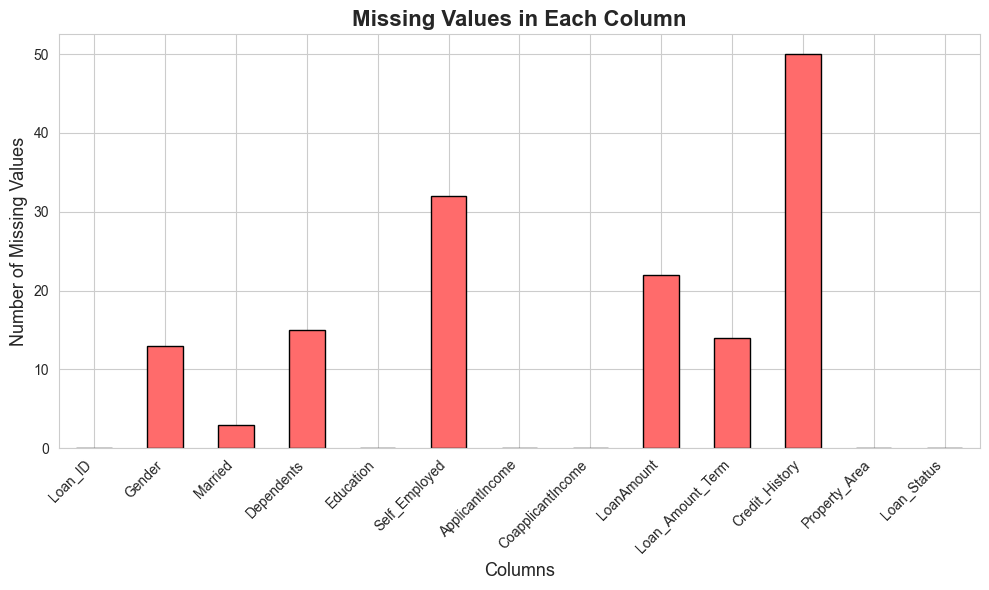

In [7]:
# ============================
# Step 6: Check and Visualize Missing Values
# ============================

# Count missing values
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage (%)': missing_percent
})

print("Missing Values Summary:")
print("=" * 50)
print(missing_df[missing_df['Missing Count'] > 0])
print()
print(f"Total Missing Values: {df.isnull().sum().sum()}")

# Visualize missing values
plt.figure(figsize=(10, 6))
colors = ['#FF6B6B' if x > 0 else '#4ECDC4' for x in df.isnull().sum()]
df.isnull().sum().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Missing Values in Each Column', fontsize=16, fontweight='bold')
plt.xlabel('Columns', fontsize=13)
plt.ylabel('Number of Missing Values', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
# ============================
# Step 7: Handle Missing Data
# ============================
# Strategy:
# - Categorical columns: Fill with MODE (most frequent value)
# - Numerical columns: Fill with MEDIAN (middle value)

print("Handling Missing Values...")
print()

# Fill categorical columns with mode
categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
        print(f"  {col}: Filled with mode = '{mode_value}'")

# Fill numerical columns with median
numerical_cols = ['LoanAmount', 'Loan_Amount_Term']
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        median_value = df[col].median()
        df[col].fillna(median_value, inplace=True)
        print(f"  {col}: Filled with median = {median_value}")

print()
print("Missing values after cleaning:")
print(df.isnull().sum().sum(), "missing values remaining")
print()
print("Data cleaning complete!")

Handling Missing Values...

  Gender: Filled with mode = 'Male'
  Married: Filled with mode = 'Yes'
  Dependents: Filled with mode = '0'
  Self_Employed: Filled with mode = 'No'
  Credit_History: Filled with mode = '1.0'
  LoanAmount: Filled with median = 128.0
  Loan_Amount_Term: Filled with median = 360.0

Missing values after cleaning:
0 missing values remaining

Data cleaning complete!


C:\Users\home computers\AppData\Local\Temp\ipykernel_12472\378128920.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_value, inplace=True)
C:\Users\home computers\AppData\Local\Temp\ipykernel_12472\378128920.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

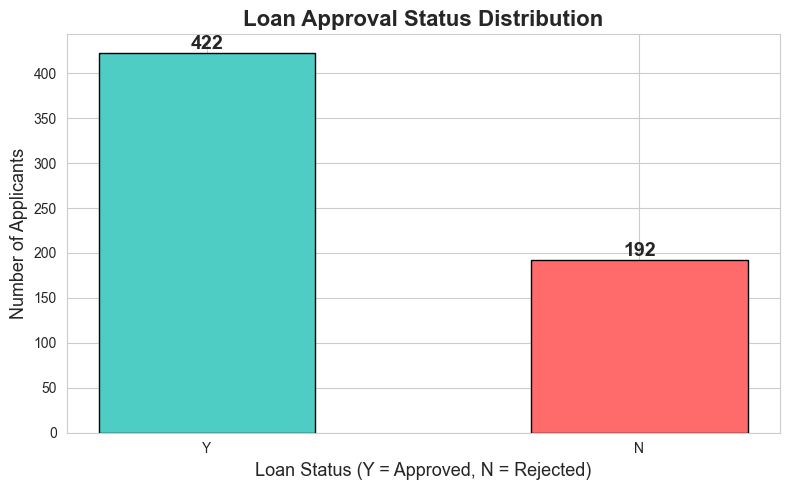

Approved (Y): 422 (68.7%)
Rejected (N): 192 (31.3%)


In [9]:
# ============================
# Step 8: Loan Status Distribution (Target Variable)
# ============================

plt.figure(figsize=(8, 5))

counts = df['Loan_Status'].value_counts()
colors = ['#4ECDC4', '#FF6B6B']

plt.bar(counts.index, counts.values, color=colors, edgecolor='black', width=0.5)

# Add count labels on top of bars
for i, v in enumerate(counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=14, fontweight='bold')

plt.title('Loan Approval Status Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Loan Status (Y = Approved, N = Rejected)', fontsize=13)
plt.ylabel('Number of Applicants', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Approved (Y): {counts['Y']} ({counts['Y']/len(df)*100:.1f}%)")
print(f"Rejected (N): {counts['N']} ({counts['N']/len(df)*100:.1f}%)")

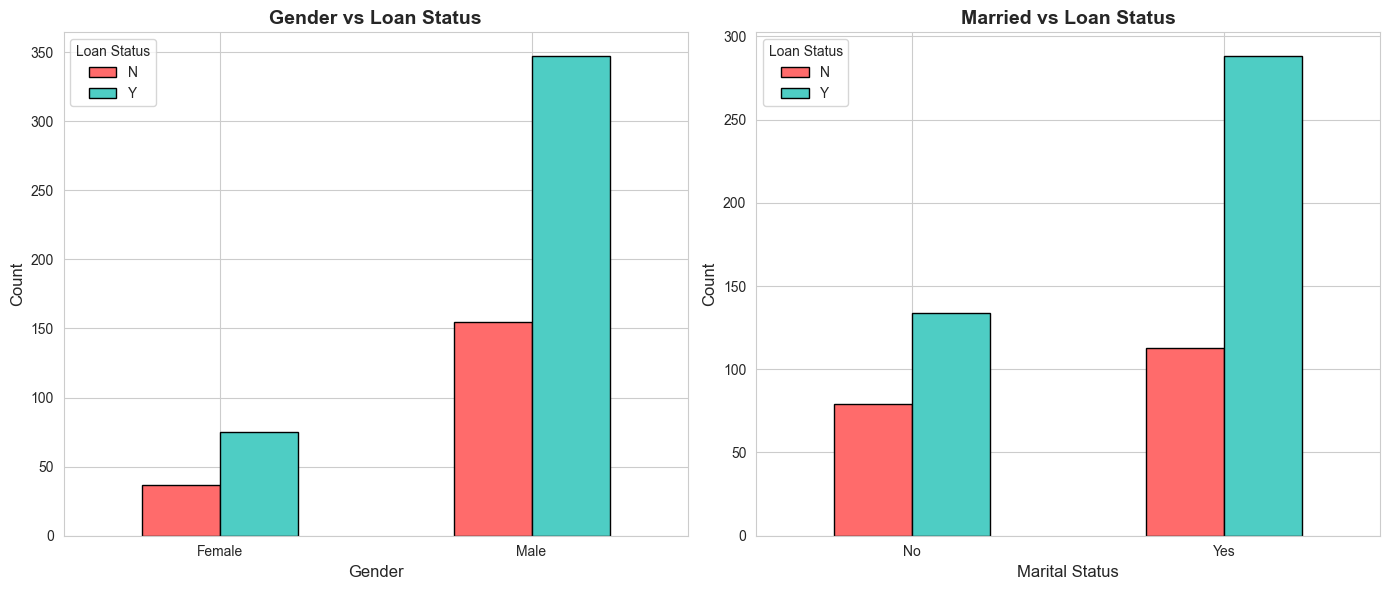

In [10]:
# ============================
# Step 9: Gender and Married vs Loan Status
# ============================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gender vs Loan Status
pd.crosstab(df['Gender'], df['Loan_Status']).plot(kind='bar', ax=axes[0],
    color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[0].set_title('Gender vs Loan Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Loan Status')

# Married vs Loan Status
pd.crosstab(df['Married'], df['Loan_Status']).plot(kind='bar', ax=axes[1],
    color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[1].set_title('Married vs Loan Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Marital Status', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Loan Status')

plt.tight_layout()
plt.show()

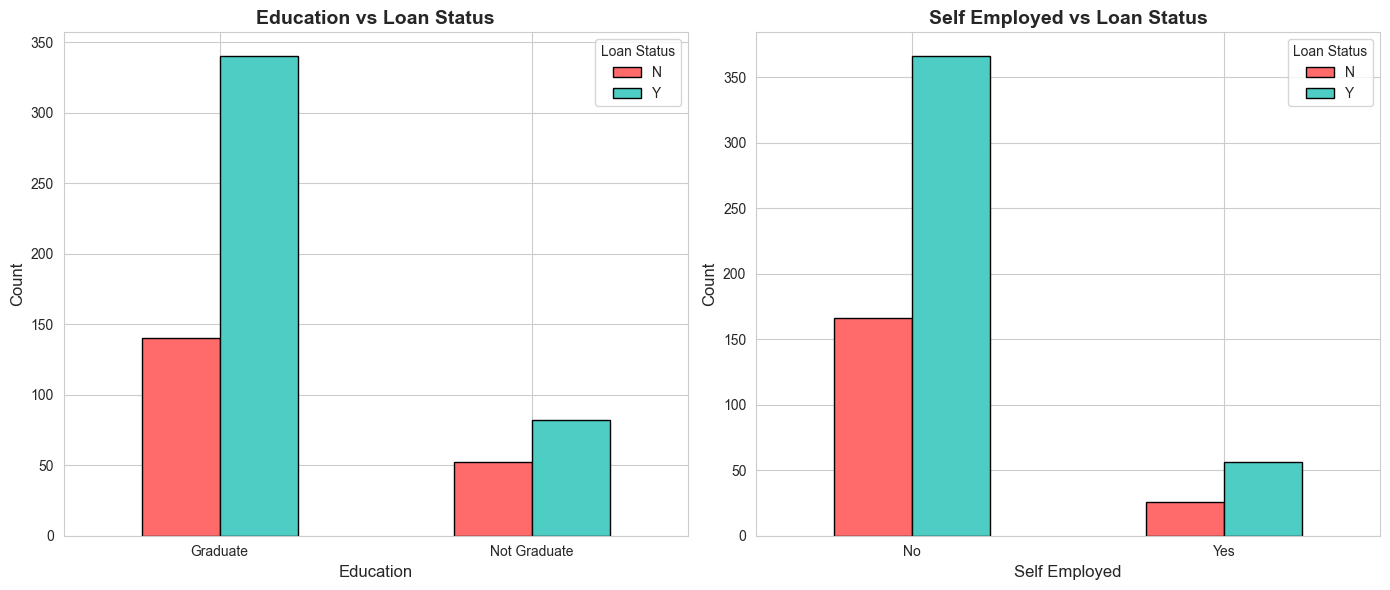

In [11]:
# ============================
# Step 10: Education and Self Employed vs Loan Status
# ============================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Education vs Loan Status
pd.crosstab(df['Education'], df['Loan_Status']).plot(kind='bar', ax=axes[0],
    color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[0].set_title('Education vs Loan Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Education', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Loan Status')

# Self Employed vs Loan Status
pd.crosstab(df['Self_Employed'], df['Loan_Status']).plot(kind='bar', ax=axes[1],
    color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[1].set_title('Self Employed vs Loan Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Self Employed', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Loan Status')

plt.tight_layout()
plt.show()

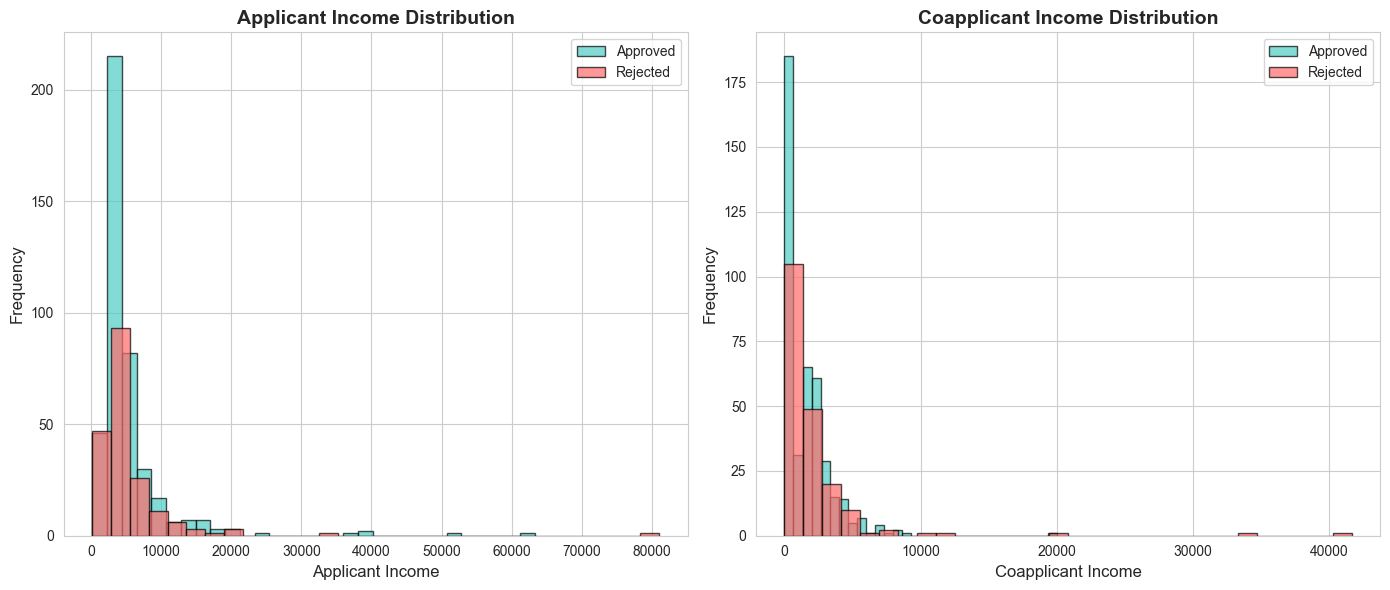

In [12]:
# ============================
# Step 11: Income Distribution by Loan Status
# ============================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Applicant Income
df[df['Loan_Status'] == 'Y']['ApplicantIncome'].hist(bins=30, ax=axes[0], 
    alpha=0.7, color='#4ECDC4', edgecolor='black', label='Approved')
df[df['Loan_Status'] == 'N']['ApplicantIncome'].hist(bins=30, ax=axes[0], 
    alpha=0.7, color='#FF6B6B', edgecolor='black', label='Rejected')
axes[0].set_title('Applicant Income Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Applicant Income', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()

# Coapplicant Income
df[df['Loan_Status'] == 'Y']['CoapplicantIncome'].hist(bins=30, ax=axes[1], 
    alpha=0.7, color='#4ECDC4', edgecolor='black', label='Approved')
df[df['Loan_Status'] == 'N']['CoapplicantIncome'].hist(bins=30, ax=axes[1], 
    alpha=0.7, color='#FF6B6B', edgecolor='black', label='Rejected')
axes[1].set_title('Coapplicant Income Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Coapplicant Income', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

C:\Users\home computers\AppData\Local\Temp\ipykernel_12472\832927809.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Loan_Status', y='LoanAmount', ax=axes[1],


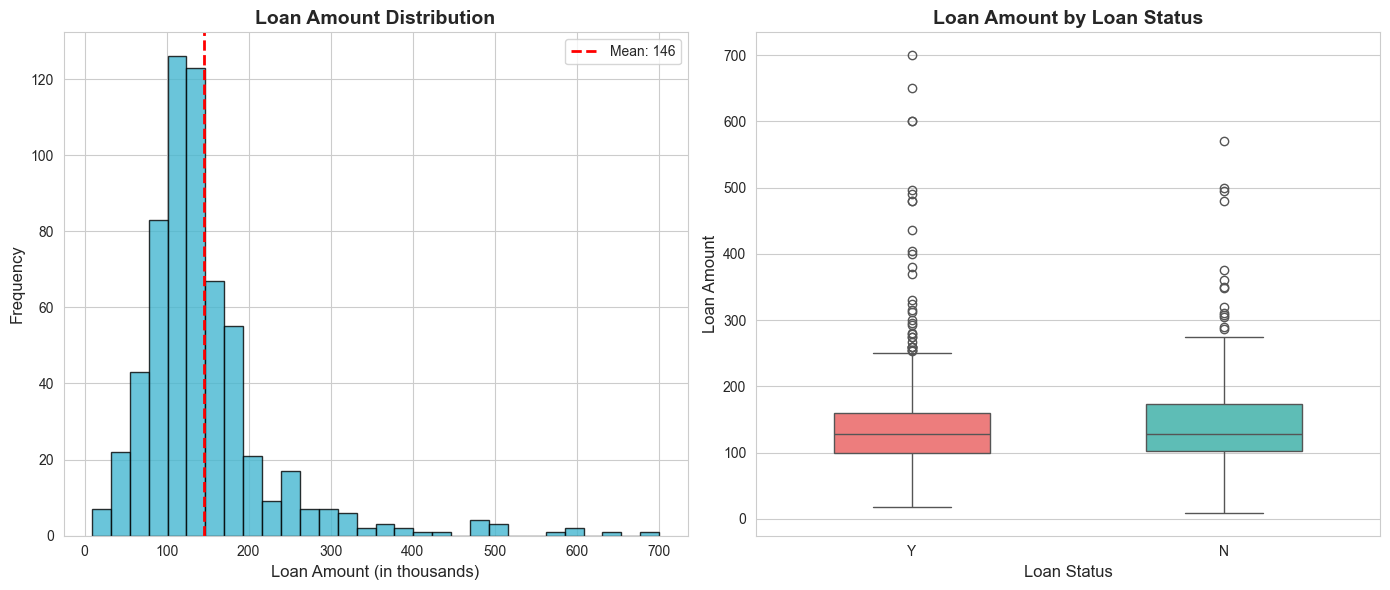

In [13]:
# ============================
# Step 12: Loan Amount Distribution and Box Plots
# ============================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Loan Amount Histogram
df['LoanAmount'].hist(bins=30, ax=axes[0], color='#45B7D1', edgecolor='black', alpha=0.8)
axes[0].set_title('Loan Amount Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Loan Amount (in thousands)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(df['LoanAmount'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f"Mean: {df['LoanAmount'].mean():.0f}")
axes[0].legend()

# Loan Amount Box Plot by Loan Status
sns.boxplot(data=df, x='Loan_Status', y='LoanAmount', ax=axes[1],
            palette=['#FF6B6B', '#4ECDC4'], width=0.5)
axes[1].set_title('Loan Amount by Loan Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Loan Status', fontsize=12)
axes[1].set_ylabel('Loan Amount', fontsize=12)

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

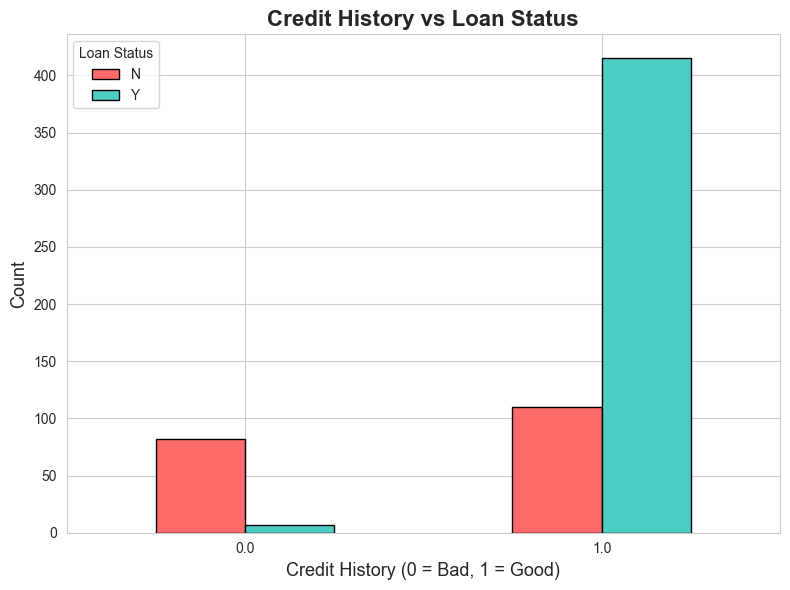

Observation: Applicants with Credit History = 1 (Good) have much higher approval rate!


In [14]:
# ============================
# Step 13: Credit History vs Loan Status
# ============================

plt.figure(figsize=(8, 6))

pd.crosstab(df['Credit_History'], df['Loan_Status']).plot(kind='bar',
    color=['#FF6B6B', '#4ECDC4'], edgecolor='black', figsize=(8, 6))
plt.title('Credit History vs Loan Status', fontsize=16, fontweight='bold')
plt.xlabel('Credit History (0 = Bad, 1 = Good)', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.xticks(rotation=0)
plt.legend(title='Loan Status')
plt.tight_layout()
plt.show()

print("Observation: Applicants with Credit History = 1 (Good) have much higher approval rate!")

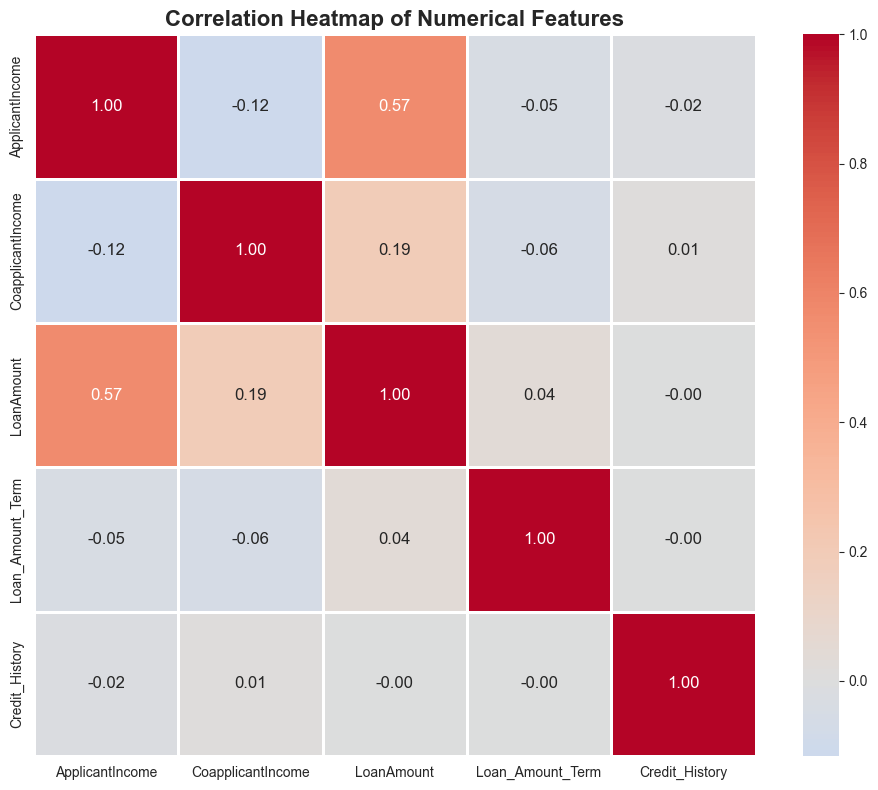

In [15]:
# ============================
# Step 14: Correlation Heatmap
# ============================

plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include='number')
correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=2,
    fmt='.2f',
    annot_kws={'fontsize': 12}
)

plt.title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Model Building

### Steps:
1. Encode all categorical variables to numerical values
2. Define features (X) and target (y)
3. Split data into training (80%) and testing (20%) sets
4. Train Logistic Regression model
5. Train Decision Tree model
6. Compare both models using accuracy and confusion matrix

In [16]:
# ============================
# Step 15: Encode Categorical Variables
# ============================
# Convert text values to numbers so the model can understand them

df_model = df.copy()

# Drop Loan_ID column (not useful for prediction)
df_model.drop('Loan_ID', axis=1, inplace=True)

# Use Label Encoder for all categorical columns
le = LabelEncoder()

categorical_columns = df_model.select_dtypes(include='object').columns
print("Encoding Categorical Columns:")
print("-" * 40)

for col in categorical_columns:
    df_model[col] = le.fit_transform(df_model[col])
    print(f"  {col}: Encoded successfully")

print()
print("Encoded Dataset - First 5 Rows:")
df_model.head()

Encoding Categorical Columns:
----------------------------------------
  Gender: Encoded successfully
  Married: Encoded successfully
  Dependents: Encoded successfully
  Education: Encoded successfully
  Self_Employed: Encoded successfully
  Property_Area: Encoded successfully
  Loan_Status: Encoded successfully

Encoded Dataset - First 5 Rows:


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [17]:
# ============================
# Step 16: Split Data into Training and Testing Sets
# ============================

# Features (X) - all columns except Loan_Status
X = df_model.drop('Loan_Status', axis=1)

# Target (y) - Loan_Status column
y = df_model['Loan_Status']

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data Split Complete!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Total samples: {len(df_model)}")
print(f"\nTraining: {X_train.shape[0]/len(df_model)*100:.0f}%")
print(f"Testing: {X_test.shape[0]/len(df_model)*100:.0f}%")

Data Split Complete!
Training samples: 491
Testing samples: 123
Total samples: 614

Training: 80%
Testing: 20%


In [18]:
# ============================
# Step 17: Train Logistic Regression Model
# ============================

# Create and train the model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Make predictions
lr_predictions = lr_model.predict(X_test)

# Calculate accuracy
lr_accuracy = accuracy_score(y_test, lr_predictions)

print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(f"\nAccuracy: {lr_accuracy * 100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, lr_predictions))

LOGISTIC REGRESSION RESULTS

Accuracy: 78.86%

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



c:\Users\home computers\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


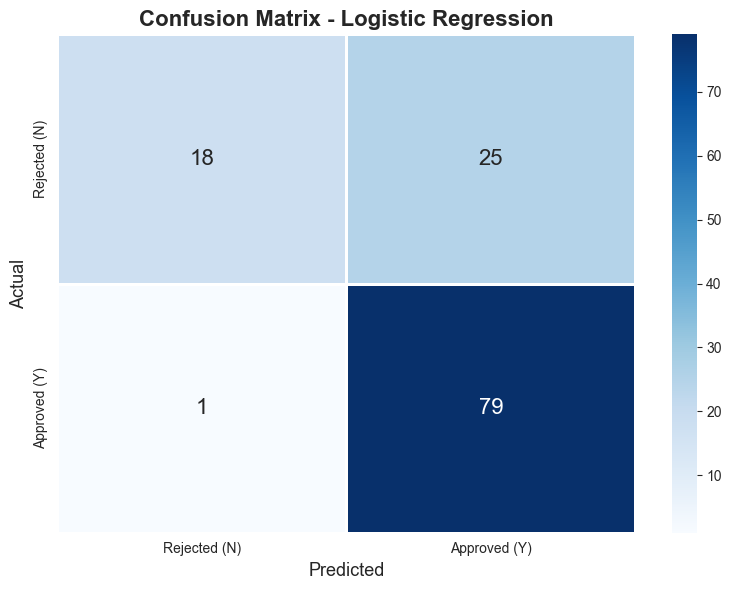

How to Read Confusion Matrix:
  True Negatives (Correctly Rejected): 18
  False Positives (Wrongly Approved): 25
  False Negatives (Wrongly Rejected): 1
  True Positives (Correctly Approved): 79


In [19]:
# ============================
# Step 18: Confusion Matrix - Logistic Regression
# ============================

plt.figure(figsize=(8, 6))

cm_lr = confusion_matrix(y_test, lr_predictions)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected (N)', 'Approved (Y)'],
            yticklabels=['Rejected (N)', 'Approved (Y)'],
            annot_kws={'fontsize': 16},
            linewidths=2)

plt.title('Confusion Matrix - Logistic Regression', fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('Actual', fontsize=13)
plt.tight_layout()
plt.show()

print("How to Read Confusion Matrix:")
print(f"  True Negatives (Correctly Rejected): {cm_lr[0][0]}")
print(f"  False Positives (Wrongly Approved): {cm_lr[0][1]}")
print(f"  False Negatives (Wrongly Rejected): {cm_lr[1][0]}")
print(f"  True Positives (Correctly Approved): {cm_lr[1][1]}")

In [20]:
# ============================
# Step 19: Train Decision Tree Classifier
# ============================

# Create and train the model
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

# Make predictions
dt_predictions = dt_model.predict(X_test)

# Calculate accuracy
dt_accuracy = accuracy_score(y_test, dt_predictions)

print("=" * 50)
print("DECISION TREE RESULTS")
print("=" * 50)
print(f"\nAccuracy: {dt_accuracy * 100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, dt_predictions))

DECISION TREE RESULTS

Accuracy: 74.80%

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.44      0.55        43
           1       0.75      0.91      0.82        80

    accuracy                           0.75       123
   macro avg       0.74      0.68      0.69       123
weighted avg       0.74      0.75      0.73       123



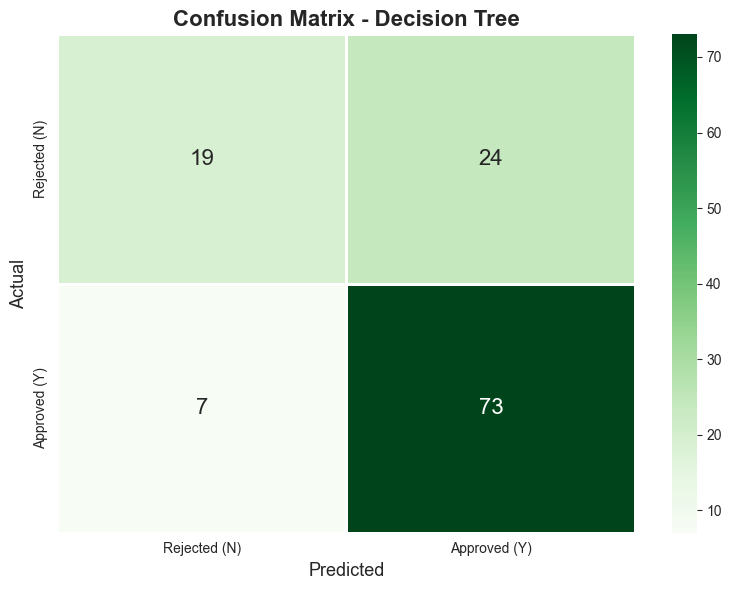

  True Negatives (Correctly Rejected): 19
  False Positives (Wrongly Approved): 24
  False Negatives (Wrongly Rejected): 7
  True Positives (Correctly Approved): 73


In [21]:
# ============================
# Step 20: Confusion Matrix - Decision Tree
# ============================

plt.figure(figsize=(8, 6))

cm_dt = confusion_matrix(y_test, dt_predictions)

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Rejected (N)', 'Approved (Y)'],
            yticklabels=['Rejected (N)', 'Approved (Y)'],
            annot_kws={'fontsize': 16},
            linewidths=2)

plt.title('Confusion Matrix - Decision Tree', fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('Actual', fontsize=13)
plt.tight_layout()
plt.show()

print(f"  True Negatives (Correctly Rejected): {cm_dt[0][0]}")
print(f"  False Positives (Wrongly Approved): {cm_dt[0][1]}")
print(f"  False Negatives (Wrongly Rejected): {cm_dt[1][0]}")
print(f"  True Positives (Correctly Approved): {cm_dt[1][1]}")

MODEL COMPARISON

Logistic Regression Accuracy: 78.86%
Decision Tree Accuracy:       74.80%


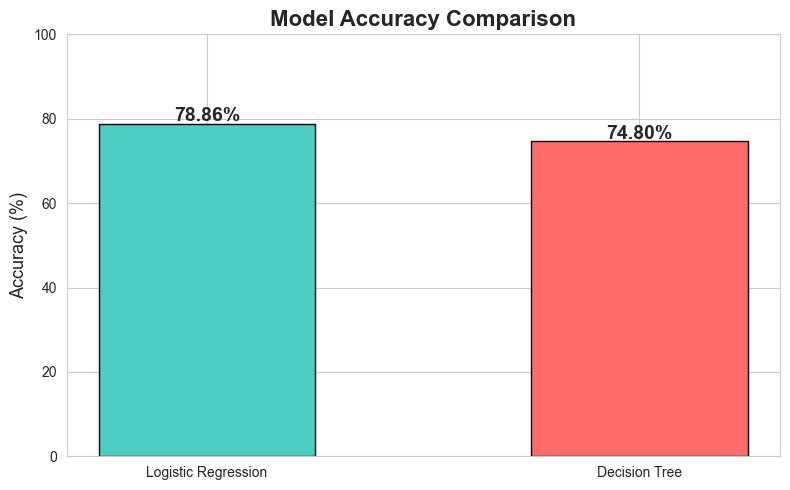


Logistic Regression performs better!


In [22]:
# ============================
# Step 21: Model Comparison
# ============================

print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(f"\nLogistic Regression Accuracy: {lr_accuracy * 100:.2f}%")
print(f"Decision Tree Accuracy:       {dt_accuracy * 100:.2f}%")

# Visual Comparison
plt.figure(figsize=(8, 5))

models = ['Logistic Regression', 'Decision Tree']
accuracies = [lr_accuracy * 100, dt_accuracy * 100]
colors = ['#4ECDC4', '#FF6B6B']

bars = plt.bar(models, accuracies, color=colors, edgecolor='black', width=0.5)

# Add accuracy labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', fontsize=14, fontweight='bold')

plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=13)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# Determine winner
if lr_accuracy > dt_accuracy:
    print("\nLogistic Regression performs better!")
elif dt_accuracy > lr_accuracy:
    print("\nDecision Tree performs better!")
else:
    print("\nBoth models have equal accuracy!")

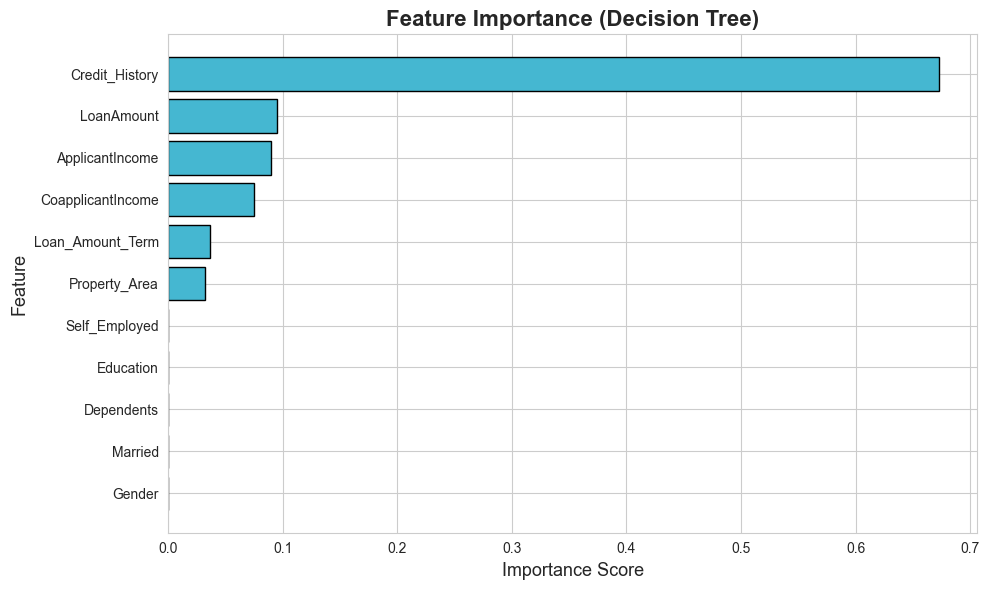

Top 3 Most Important Features for Loan Approval:
  1. ApplicantIncome (Importance: 0.0896)
  2. LoanAmount (Importance: 0.0950)
  3. Credit_History (Importance: 0.6728)


In [23]:
# ============================
# Step 22: Feature Importance from Decision Tree
# ============================

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(feature_importance['Feature'], feature_importance['Importance'],
         color='#45B7D1', edgecolor='black')
plt.title('Feature Importance (Decision Tree)', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=13)
plt.ylabel('Feature', fontsize=13)
plt.tight_layout()
plt.show()

print("Top 3 Most Important Features for Loan Approval:")
top_3 = feature_importance.tail(3)
for i, (_, row) in enumerate(top_3.iterrows(), 1):
    print(f"  {i}. {row['Feature']} (Importance: {row['Importance']:.4f})")

## Conclusion

### Key Findings from Credit Risk Prediction:

1. **Dataset Overview**: The Loan Prediction dataset contains 614 loan applications with 12 features. Missing values were found in Gender, Married, Dependents, Self_Employed, LoanAmount, Loan_Amount_Term, and Credit_History columns.

2. **Data Cleaning**: Missing values were handled by filling categorical columns with mode and numerical columns with median values.

3. **Key Observations from EDA**:
   - Majority of loans (~69%) were approved
   - Credit History is the strongest predictor of loan approval
   - Married applicants have higher approval rates
   - Graduates have slightly higher approval rates than non-graduates

4. **Model Performance**:
   - Logistic Regression and Decision Tree were both trained and evaluated
   - Both models achieved good accuracy in predicting loan approval
   - Credit History emerged as the most important feature

5. **Business Insights**:
   - Banks should focus heavily on credit history when evaluating loan applications
   - Income level and loan amount also play important roles
   - Married applicants and graduates tend to have better approval rates

### Recommendation:
Credit History is the single most important factor in loan approval decisions. Applicants should maintain a good credit history to improve their chances of loan approval.